In [ ]:
#%%
"""
ONE LDA SPACE FOR ALL TIMEPOINTS
================================
Goal: an embedding that segregates MICE, independently of learning stage.

The trap this notebook is built to avoid: if you pool all timepoints and fit a
mouse-discriminating LDA on the raw features, the largest structure in the data is
TIMEPOINT, not mouse -- the rig and camera differ between training and ephys, and
reaction times change with learning. Mice would then appear to separate merely
because each mouse's sessions cluster by timepoint, i.e. you would be looking at
learning structure and calling it individuality.

Fix (agreed): remove the timepoint main effect FIRST, by z-scoring every feature
WITHIN each timepoint, then fit the mouse LDA on the pooled residuals. "Independent
of learning" is then true by construction rather than by hope.

Three checks make the claim testable rather than assumed:
  1. can timepoint still be decoded after standardisation?  (should collapse)
  2. how does the variance split between mouse and timepoint?
  3. does a mouse classifier trained on some timepoints work on a HELD-OUT
     timepoint?  (the real test of learning-independence)
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

#%%
def filter_sequences(all_sequences, min_sessions=1):
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    cnt = (all_sequences[['mouse_name','session']].drop_duplicates()
           .groupby(['mouse_name'])['session'].count().reset_index())
    keep = cnt.loc[cnt['session'] >= min_sessions, 'mouse_name']
    return all_sequences.loc[all_sequences['mouse_name'].isin(keep)].reset_index(drop=True)


def binarize(use_sequences, n_paw_states=8, keep_paw=True, keep_whisk=True, keep_lick=True):
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type must be kept.")
    n_raw = n_paw_states + 2
    n_trials, timesteps = use_sequences.shape
    out = np.zeros((n_trials, timesteps * n_raw))
    for t in range(timesteps):
        vals = use_sequences[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int); start = t * n_raw
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + (labels % n_paw_states)] = 1
            out[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            out[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            out[nan_mask, start:start + n_raw] = np.nan
    cols = []
    if keep_paw:   cols += [i for i in range(n_paw_states) if i != 1]
    if keep_whisk: cols += [n_paw_states]
    if keep_lick:  cols += [n_paw_states + 1]
    return out[:, [t * n_raw + c for t in range(timesteps) for c in cols]]


def build_multi_timepoint(files_by_label, keep_paw=True, keep_whisk=True, keep_lick=True,
                          min_sessions_by_label=None, exclude_by_label=None):
    """Session-level design matrix pooled over timepoints, with a timepoint label."""
    # BAD-SESSION EXCLUSION, APPLIED TO EVERY TIMEPOINT.
    # filter_sequences drops `prob_sessions` (the globally bad sessions) from every
    # file. On top of that, the sweep excludes a per-timepoint list -- session_1 for
    # Early and last_training for Late (lda_sweep_timepoints.py: exclude_sessions =
    # [session_1, last_training, []]). Those were previously applied to nothing here,
    # so 18 Early and 12 Late sessions that the sweep discards were being kept.
    min_sessions_by_label = min_sessions_by_label or {}
    exclude_by_label = exclude_by_label or {}
    frames = []
    for label, path in files_by_label.items():
        seq = pd.read_parquet(path)
        seq['session'] = seq['sample'].str[:36]
        n0 = seq['session'].nunique()
        seq = filter_sequences(seq, min_sessions=min_sessions_by_label.get(label, 1))
        n1 = seq['session'].nunique()
        drop = list(exclude_by_label.get(label, []))
        if drop:
            seq = seq.loc[~seq['session'].isin(drop)]
        n2 = seq['session'].nunique()
        print(f"  {label:11s} {n0:4d} sessions -> {n1:4d} after prob_sessions/min_sessions"
              f" -> {n2:4d} after the {label} exclusion list "
              f"({n0-n1} + {n1-n2} dropped)")
        seq['timepoint'] = label
        frames.append(seq)
    allseq = pd.concat(frames)
    design = (allseq.pivot(index=['mouse_name','session','sample','trial_type','timepoint'],
                           columns=['broader_label'], values='binned_sequence')
              .reset_index().dropna())
    design = design.sort_values(by=['timepoint','session'])
    epochs = ['Pre-quiescence','Quiescence','Choice','ITI']
    seqs = np.vstack(design[epochs].apply(lambda r: np.hstack(r), axis=1))
    feats = binarize(seqs, 8, keep_paw, keep_whisk, keep_lick)
    tmp = pd.DataFrame(feats); tmp['session'] = design['session'].values
    per = tmp.groupby('session', sort=False)[np.arange(feats.shape[1])].mean()
    bad = per.isna().any(axis=0)
    if bad.sum():
        print(f"!! dropping {int(bad.sum())} all-NaN features"); per = per.loc[:, ~bad]
    meta = (design[['session','mouse_name','timepoint']].drop_duplicates()
            .set_index('session').reindex(per.index))
    print(f"✓ {len(per)} sessions, {per.shape[1]} features, {meta.mouse_name.nunique()} mice")
    print(meta.groupby('timepoint').agg(sessions=('mouse_name','size'),
                                        mice=('mouse_name','nunique')).to_string())
    return np.asarray(per), meta['mouse_name'].values, meta['timepoint'].values


def standardize_within_timepoint(X, timepoint, fit_mask=None, eps=1e-8):
    """
    Z-score every feature SEPARATELY WITHIN each timepoint. This is what removes the
    timepoint main effect: after it, no feature has a timepoint-specific mean or
    scale, so a mouse classifier cannot ride on "this looks like a training rig".

    fit_mask : if given, the mean/sd of each timepoint are computed from those rows
               only (use the training rows inside cross-validation, so the held-out
               sessions do not contribute to their own standardisation).

    NOTE it removes means and scales, NOT covariance structure. Check 1 below tests
    how much timepoint information actually survives.
    """
    Xs = np.array(X, dtype=float)
    if fit_mask is None:
        fit_mask = np.ones(len(X), bool)
    for tp in np.unique(timepoint):
        rows = timepoint == tp
        ref = rows & fit_mask
        if ref.sum() < 2:
            continue
        mu = Xs[ref].mean(0); sd = Xs[ref].std(0)
        Xs[rows] = (Xs[rows] - mu) / (sd + eps)
    return Xs


def variance_partition(values, mice, timepoint):
    """
    How much of the variance in each embedding dimension is explained by mouse
    identity, by timepoint, and by both? Dummy-coded least squares, reported as R².
    Mouse and timepoint are not orthogonal here (mice differ in which timepoints
    they have), so the two R² do not have to sum to the joint one.
    """
    def r2(D, y):
        D = np.column_stack([np.ones(len(y)), D])
        beta, *_ = np.linalg.lstsq(D, y, rcond=None)
        resid = y - D @ beta
        return 1 - resid.var() / y.var()
    Dm = pd.get_dummies(pd.Series(mice), drop_first=True).values.astype(float)
    Dt = pd.get_dummies(pd.Series(timepoint), drop_first=True).values.astype(float)
    rows = []
    for j in range(values.shape[1]):
        y = values[:, j]
        rows.append(dict(dim=f'LD{j+1}', mouse=r2(Dm, y), timepoint=r2(Dt, y),
                         both=r2(np.column_stack([Dm, Dt]), y)))
    return pd.DataFrame(rows)


In [2]:
#%%
""" CONFIG AND BUILD """

""" SESSION EXCLUSIONS -- from the curated QC sheet, not hardcoded lists """
from session_filters import exclusions_by_timepoint, report_exclusions

# THE FILTER PARAMETER:
#   'filtered_out'            -> drop Used in paper == 'filtered out'
#   'filtered_out_and_revise' -> drop those PLUS 'need to revise'
QC_STRICTNESS = 'filtered_out'

EXCLUDE_BY_LABEL = exclusions_by_timepoint(QC_STRICTNESS)
# filter_sequences() still applies this to every file; it is now the sheet's
# proficient exclusions rather than the old hand-maintained prob_sessions list.
prob_sessions = EXCLUDE_BY_LABEL['Proficient']
print(f"exclusions from the sheet ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in EXCLUDE_BY_LABEL.items()))

BIN = '8_k_10_bin'
FILES = {
    'Early':      base_path + f'training/paw_wheel_session_1_{BIN}_syllables_28-08-2026',
    'Late':       base_path + f'training/paw_wheel_last_training_{BIN}_syllables_28-08-2026',
    'Pre-rec':    base_path + f'training/paw_wheel_biased_{BIN}_syllables_28-08-2026',
    'Proficient': base_path + f'paw_wheel_{BIN}_syllables_28-08-2026',
}
ORDER  = ['Early','Late','Pre-rec','Proficient']
COLORS = {'Early':'#ECA307','Late':'#B40AE7','Pre-rec':'#22AA06','Proficient':'#1F6FEB'}
N_PCS, N_LDS = 20, 3

X_raw, mice, timepoint = build_multi_timepoint(FILES, exclude_by_label=EXCLUDE_BY_LABEL)

# THE standardisation step: remove the timepoint main effect
X_std = standardize_within_timepoint(X_raw, timepoint)
# For comparison: pooled z-scoring, which leaves the timepoint effect in
X_pooled = StandardScaler().fit_transform(X_raw)
print("\nbuilt: X_raw, X_std (within-timepoint z-scored), X_pooled (naive)")


✓ 532 sessions, 360 features, 101 mice
            sessions  mice
timepoint                 
Early             38    38
Late              46    46
Pre-rec          116    43
Proficient       332   101

built: X_raw, X_std (within-timepoint z-scored), X_pooled (naive)


In [3]:
#%%
"""
CHECK 1 -- did the standardisation actually remove the timepoint effect?
Decode TIMEPOINT from the features. If within-timepoint z-scoring worked, this
should fall towards chance (1/n_timepoints). Whatever survives is timepoint
information carried by the covariance rather than the means, which standardisation
cannot remove.
"""
def decode_timepoint(X, timepoint, n_splits=5):
    y = pd.factorize(timepoint)[0]
    accs = []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    for tr, te in skf.split(X, y):
        pipe_pca = PCA(n_components=min(N_PCS, len(tr)-1, X.shape[1]), random_state=0).fit(X[tr])
        clf = LogisticRegression(max_iter=5000, C=1.0).fit(pipe_pca.transform(X[tr]), y[tr])
        accs.append(clf.score(pipe_pca.transform(X[te]), y[te]))
    return float(np.mean(accs))

chance_tp = 1 / len(np.unique(timepoint))
print(f"timepoint decoding accuracy (chance = {chance_tp:.3f}):")
print(f"  raw features              : {decode_timepoint(X_raw, timepoint):.3f}")
print(f"  pooled z-score (naive)    : {decode_timepoint(X_pooled, timepoint):.3f}")
print(f"  within-timepoint z-score  : {decode_timepoint(X_std, timepoint):.3f}   <- should be lowest")

#%%
"""
CHECK 2 -- variance partition of the embedding.
Fit the mouse LDA on the standardised, pooled data, then ask how much of each LD
is explained by mouse identity versus by timepoint. A good embedding has high mouse
R² and low timepoint R².
"""
def fit_mouse_lda(X, mice, n_pcs=N_PCS, n_lds=N_LDS):
    pca = PCA(n_components=min(n_pcs, len(X)-1, X.shape[1]), random_state=0).fit(X)
    Z = pca.transform(X)
    n_classes = len(np.unique(mice))
    n_lds = min(n_lds, n_classes-1, Z.shape[1])
    lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto',
                                     priors=np.ones(n_classes)/n_classes, n_components=n_lds)
    lda.fit(Z, mice)
    return lda.transform(Z)[:, :n_lds], dict(pca=pca, lda=lda)

coords_std, frame_std = fit_mouse_lda(X_std, mice)
coords_pool, _        = fit_mouse_lda(X_pooled, mice)

print("\nvariance partition, WITHIN-TIMEPOINT standardised (the agreed approach):")
print(variance_partition(coords_std, mice, timepoint).to_string(index=False,
      float_format=lambda v: f'{v:.3f}'))
print("\nvariance partition, POOLED z-score (for contrast -- expect timepoint to matter):")
print(variance_partition(coords_pool, mice, timepoint).to_string(index=False,
      float_format=lambda v: f'{v:.3f}'))


timepoint decoding accuracy (chance = 0.250):
  raw features              : 0.887
  pooled z-score (naive)    : 0.880
  within-timepoint z-score  : 0.618   <- should be lowest


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_empirical_covariance.py:102: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_empirical_covariance.py:102: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to resha


variance partition, WITHIN-TIMEPOINT standardised (the agreed approach):
dim  mouse  timepoint  both
LD1  0.738      0.000 0.739
LD2  0.694     -0.000 0.696
LD3  0.705      0.000 0.708

variance partition, POOLED z-score (for contrast -- expect timepoint to matter):
dim  mouse  timepoint  both
LD1  0.711      0.001 0.713
LD2  0.745      0.010 0.754
LD3  0.656      0.010 0.660


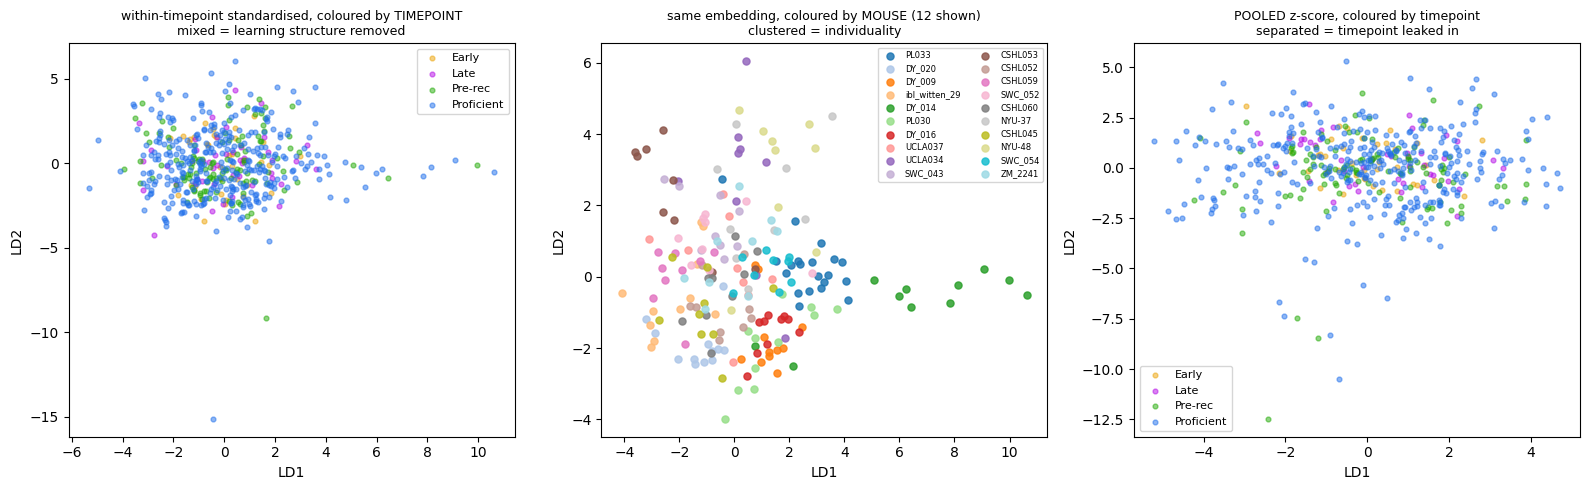

held-out      mice  ntrain  ntest     acc  shuffled     1/n  x chance
Early           38     264     38   0.026     0.020   0.026       1.0
Late            46     345     46   0.065     0.025   0.022       3.0
Pre-rec         43     248    116   0.026     0.019   0.023       1.1


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_empirical_covariance.py:102: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_empirical_covariance.py:102: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to resha

Proficient      57     200    266   0.015     0.020   0.018       0.9


In [6]:
#%%
""" THE EMBEDDING """
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) coloured by TIMEPOINT -- should look MIXED if learning was removed
ax = axes[0]
for lab in ORDER:
    s = timepoint == lab
    ax.scatter(coords_std[s,0], coords_std[s,1], s=12, alpha=0.5, color=COLORS[lab], label=lab)
ax.set_xlabel('LD1'); ax.set_ylabel('LD2'); ax.legend(fontsize=8)
ax.set_title('within-timepoint standardised, coloured by TIMEPOINT\n'
             'mixed = learning structure removed', fontsize=9)

# (b) coloured by MOUSE -- should look CLUSTERED
ax = axes[1]
show = pd.Series(mice).value_counts().index[:20]      # 12 mice for legibility
cmap = plt.cm.tab20(np.linspace(0,1,len(show)))
for c,m in zip(cmap, show):
    s = mice == m
    ax.scatter(coords_std[s,0], coords_std[s,1], s=26, color=c, label=m, alpha=0.85)
ax.set_xlabel('LD1'); ax.set_ylabel('LD2'); ax.legend(fontsize=6, ncol=2)
ax.set_title('same embedding, coloured by MOUSE (12 shown)\nclustered = individuality', fontsize=9)

# (c) the naive alternative, coloured by timepoint -- the thing we are avoiding
ax = axes[2]
for lab in ORDER:
    s = timepoint == lab
    ax.scatter(coords_pool[s,0], coords_pool[s,1], s=12, alpha=0.5, color=COLORS[lab], label=lab)
ax.set_xlabel('LD1'); ax.set_ylabel('LD2'); ax.legend(fontsize=8)
ax.set_title('POOLED z-score, coloured by timepoint\nseparated = timepoint leaked in', fontsize=9)
plt.tight_layout(); plt.show()

#%%
"""
CHECK 3 -- the real test of learning-independence.
Train the mouse classifier on some timepoints and test it on a HELD-OUT timepoint.
If mouse identity is readable independently of learning stage, this generalises.
Standardisation and PCA are fit on the TRAINING timepoints only.

Chance is 1/n_mice among the mice that appear in both the train and test timepoints.
The shuffle control re-labels mice within the training set.
"""
def leave_one_timepoint_out(X_raw, mice, timepoint, test_tp, n_pcs=N_PCS, n_shuffle=20):
    tr_mask = timepoint != test_tp
    te_mask = timepoint == test_tp
    shared = np.intersect1d(np.unique(mice[tr_mask]), np.unique(mice[te_mask]))
    tr = tr_mask & np.isin(mice, shared)
    te = te_mask & np.isin(mice, shared)
    if tr.sum() < 10 or te.sum() < 3 or len(shared) < 3:
        return None
    # standardisation fit on TRAINING rows only
    Xs = standardize_within_timepoint(X_raw, timepoint, fit_mask=tr)
    pca = PCA(n_components=min(n_pcs, tr.sum()-1, X_raw.shape[1]), random_state=0).fit(Xs[tr])
    Ztr, Zte = pca.transform(Xs[tr]), pca.transform(Xs[te])
    n_classes = len(shared)
    def score(labels):
        lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto',
                                         priors=np.ones(len(np.unique(labels)))/len(np.unique(labels)))
        lda.fit(Ztr, labels)
        return lda.score(Zte, mice[te])
    acc = score(mice[tr])
    rng = np.random.default_rng(0)
    null = []
    for _ in range(n_shuffle):
        lab = mice[tr].copy(); rng.shuffle(lab); null.append(score(lab))
    return dict(test_tp=test_tp, n_mice=n_classes, n_train=int(tr.sum()), n_test=int(te.sum()),
                acc=acc, null=float(np.mean(null)), chance=1/n_classes)

print(f"{'held-out':12s} {'mice':>5s} {'ntrain':>7s} {'ntest':>6s} {'acc':>7s} "
      f"{'shuffled':>9s} {'1/n':>7s} {'x chance':>9s}")
for tp in ORDER:
    r = leave_one_timepoint_out(X_raw, mice, timepoint, tp)
    if r is None:
        print(f"{tp:12s} (too few shared mice)"); continue
    print(f"{r['test_tp']:12s} {r['n_mice']:5d} {r['n_train']:7d} {r['n_test']:6d} "
          f"{r['acc']:7.3f} {r['null']:9.3f} {r['chance']:7.3f} {r['acc']/r['chance']:9.1f}")
